In [2]:
import pickle
import numpy as np
import os 
import torch
import matplotlib.pyplot as plt 


In [331]:
# orig = torch.load('../originals_means.pickle')
# out = torch.load('../model_out_means.pickle')
# embed = torch.load('../embeddings_means.pickle')

# orig = torch.load('../originals_time.pickle')
# out = torch.load('../model_out_time.pickle')
# embed = torch.load('../embeddings_time.pickle')

# orig = torch.load('../originals_time.pickle')
# out = torch.load('../model_out_time.pickle')
# embed = torch.load('../embeddings_time.pickle')
# nodes = torch.load('../actuals_time.pickle')


orig = torch.load('../train_originals_time.pickle')
out = torch.load('../train_model_out_time.pickle')
embed = torch.load('../train_embeddings_time.pickle')
nodes = torch.load('../train_actuals_time.pickle')


In [257]:
# print(orig[0][0]])
# fil2 = open('./data/1000_len_sims/graphs/alltesttime.pickle', 'rb')
# metatime = pickle.load(fil2)
# fil2.close()
# fil2 = open('./data/1000_len_sims/graphs/alltestsucc.pickle', 'rb')
# metasucc = pickle.load(fil2)
# fil2.close()

fil2 = open('./data/1000_len_sims/graphs/alltraintime.pickle', 'rb')
metatime = pickle.load(fil2)
fil2.close()
fil2 = open('./data/1000_len_sims/graphs/alltrainsucc.pickle', 'rb')
metasucc = pickle.load(fil2)
fil2.close()

In [268]:
print(np.shape(orig[0]), np.shape(out[0]), np.shape(nodes[0]), np.shape(embed[0]))

torch.Size([1, 1077]) torch.Size([1077, 1]) torch.Size([1077, 54]) torch.Size([1077, 1])


In [332]:
# def round_function_tuple(x, d):
#     new = []
#     for r in x:
#         new.append(np.round(r,decimals=d))
#     # pdb.set_trace()
#     return tuple(new)

# from collections import defaultdict
# dt_in = defaultdict(list)
# ds_in = defaultdict(list)
# dt_out = defaultdict(list)
# ds_out = defaultdict(list)

# for n, i, o in zip(nodes, orig, out):
#     # print(n,i,o)
#     # break
#     for nn, ii, oo in zip(n, i[0], o):
#         # print
#         # print(tuple(nn))
#         # for m in metatime:
#         #     print(m)
#         #     break
#         # print(nn,ii,oo.tolist()[0], metatime[round_function_tuple(tuple(nn.tolist()), 3)])
#         # break
#         curr_node = round_function_tuple(tuple(nn.tolist()), 3)
#         # print(metatime[curr_node])
#         dt_in[curr_node].append(metatime[curr_node])
#         # ds_in[n].append(metasucc[tuple(nn)])
#         dt_out[curr_node].append(oo.tolist()[0])
#         # ds_out[n].append(o[0])
#     #     break
#     # break
import pandas as  pd 
from ast import literal_eval
metadata = pd.read_csv('./data/sometest/train/metadata.csv')
metadata.site_qualities=metadata.site_qualities.apply(literal_eval)
metadata.site_positions=metadata.site_positions.apply(literal_eval)
metadata.site_positions=metadata.site_positions.apply(lambda x: tuple([tuple(a) for a in x]))
metadata.site_qualities=metadata.site_qualities.apply(lambda x: tuple(x))
# metadata.node=metadata.node.apply(literal_eval)
# metadata.sims_train = metadata.sims_train.apply(lambda x: literal_eval(x))
# metadata.site_converged = metadata.site_converged.apply(lambda x: literal_eval(x))
# metadata.time_converged = metadata.time_converged.apply(lambda x: literal_eval(x))
df = metadata.groupby(by=['site_qualities', 'site_positions', 'num_agents', 'node'], as_index=False).agg(lambda x: x.tolist())
# df = metadata.groupby(by=['start_state'], as_index=False).agg(lambda x: x.tolist())

# convtimes = pd.read_csv('./data/sometest/test/graphs/time.csv')
# list_of_nodes =
def round_function_tuple(x, d):
    new = []
    for r in x:
        new.append(np.round(r,decimals=d))
    # pdb.set_trace()
    return tuple(new)
import pdb 
from collections import defaultdict
dt_in = defaultdict(list)
ds_in = defaultdict(list)
dt_out = defaultdict(list)
ds_out = defaultdict(list)

for n, i, o in zip(nodes, orig, out):
    # print(n,i,o)
    # print(np.shape(n), np.shape(i), np.shape(o))
    # break
    # for nn, ii, oo in zip(n, i, o):
    for nn, oo in zip(n, o):
        # print(nn, ii, oo)
        # print
        # print(tuple(nn))
        # for m in metatime:
        #     print(m)
        #     break
        # print(nn,ii,oo.tolist()[0], metatime[round_function_tuple(tuple(nn.tolist()), 3)])
        # break
        curr_node = round_function_tuple(tuple(nn.tolist()), 3)
        # print(metatime[curr_node])
        # print(curr_node)
        # print(metatime[curr_node])
        # pdb.set_trace()
        # if curr_node==(0.1, 0.0, 0.0, 0.0, 0.0, 0.1, 0.2, 0.0, 0.0, 0.0, 0.2, 0.0, 0.2, 0.0, 0.0, 0.0, 0.2, 0.0, 0.3, 0.0, 0.0, 0.0, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, -0.15, 0.684, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0):
        #     print('here')
        #     mask = metadata['node'] == str(curr_node)
        #     print(mask.any())
        #     print(mask)
        #     break
            # exit
        mask = df['node'] == str(curr_node)
        if mask.any() == True:
            # print(mask)
            # print(curr_node)
            # print(np.sum([1 for m in mask if m]))
            times = df.loc[mask, 'time_converged']
            # times = df.loc[mask]
            # print(times.tolist()[0])
            # pdb.set_trace()
            dt_in[curr_node].append(times.tolist()[0])
            # ds_in[n].append(metasucc[tuple(nn)])
            # print(oo.tolist())
            dt_out[curr_node].append(oo.tolist())
            # ds_out[n].append(o[0])
            # break
    # break



In [3]:
# def round_function_tuple(x, d):
#     new = []
#     for r in x:
#         new.append(np.round(r,decimals=d))
#     # pdb.set_trace()
#     return tuple(new)

# from collections import defaultdict
# dt_in = defaultdict(list)
# ds_in = defaultdict(list)
# dt_out = defaultdict(list)
# ds_out = defaultdict(list)

# for n, i, o in zip(nodes, orig, out):
#     # print(n,i,o)
#     # break
#     for nn, ii, oo in zip(n, i[0], o):
#         # print
#         # print(tuple(nn))
#         # for m in metatime:
#         #     print(m)
#         #     break
#         # print(nn,ii,oo.tolist()[0], metatime[round_function_tuple(tuple(nn.tolist()), 3)])
#         # break
#         curr_node = round_function_tuple(tuple(nn.tolist()), 3)
#         # print(metatime[curr_node])
#         dt_in[curr_node].append(metatime[curr_node])
#         # ds_in[n].append(metasucc[tuple(nn)])
#         dt_out[curr_node].append(oo.tolist()[0])
#         # ds_out[n].append(o[0])
#     #     break
#     # break

# orig = torch.load('../originals_time.pickle')
# out = torch.load('../model_out_time.pickle')
# embed = torch.load('../embeddings_time.pickle')
# nodes = torch.load('../actuals_time.pickle')

# fil2 = open('./data/1000_len_sims/graphs/alltesttime.pickle', 'rb')
# metatime = pickle.load(fil2)
# fil2.close()
# fil2 = open('./data/1000_len_sims/graphs/alltestsucc.pickle', 'rb')
# metasucc = pickle.load(fil2)
# fil2.close()


orig = torch.load('../train_originals_time.pickle')
out = torch.load('../train_model_out_time.pickle')
embed = torch.load('../train_embeddings_time.pickle')
nodes = torch.load('../train_actuals_time.pickle')

fil2 = open('./data/1000_len_sims/graphs/alltraintime.pickle', 'rb')
metatime = pickle.load(fil2)
fil2.close()
fil2 = open('./data/1000_len_sims/graphs/alltrainsucc.pickle', 'rb')
metasucc = pickle.load(fil2)
fil2.close()
import pandas as  pd 
from ast import literal_eval

# list_of_nodes =
def round_function_tuple(x, d):
    new = []
    for r in x:
        new.append(np.round(r,decimals=d))
    # pdb.set_trace()
    return tuple(new)
import pdb 
from collections import defaultdict
dt_in = defaultdict(list)
ds_in = defaultdict(list)
dt_out = defaultdict(list)
ds_out = defaultdict(list)

for n, i, o in zip(nodes, orig, out):
    # print(n,i,o)
    # print(np.shape(n), np.shape(i), np.shape(o))
    # break
    for nn, ii, oo in zip(n, i, o):

        curr_node = round_function_tuple(tuple(nn.tolist()), 3)
        # print(curr_node)
        # print(metatime[curr_node])
        dt_in[curr_node].append(metatime[curr_node])
        # ds_in[n].append(metasucc[tuple(nn)])
        # print(oo.tolist())
        dt_out[curr_node].append(oo.tolist())
        # ds_out[n].append(o[0])
    #     break
    # break

# print(metatime)
# print(curr_node)


In [343]:
# meta
for m in metatime:
    print(m)
    break

(0.0, -0.15, 0.0, 0.87, 0.0, -0.15, 0.0, 0.87, 0.333, -0.15, 0.0, 0.87, 0.333, -0.15, 0.0, 0.87, 0.333, -0.15, 0.0, 0.87, 0.333, -0.15, 0.0, 0.87, 0.5, -0.15, 0.0, 0.87, 0.5, -0.15, 0.0, 0.87, 0.833, 1.0, 1.0, 0.0, 0.833, 1.0, 1.0, 0.0)


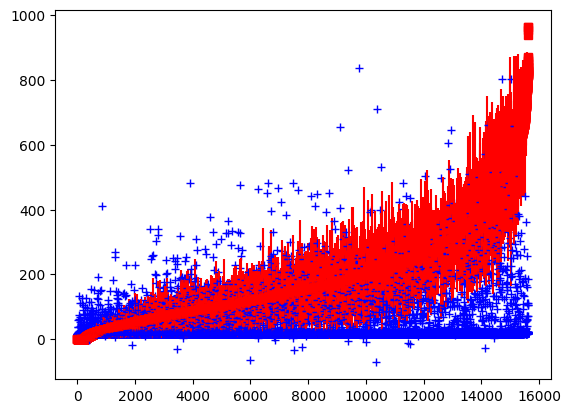

In [4]:
keys = list(dt_in.keys())
# values = list(dt_in.values())
# keys = []
sorted_dict = sorted(dt_in.items(), key=lambda item: np.mean(item[1][0]))
# sorted_dict = sorted(dt_in.items(), key=lambda item: len(item[1][0]))
keys = [item[0] for item in sorted_dict]
# print(dt_in[keys[0]])

# # import random
# # random.shuffle(keys)
plt.figure(0)
for id, node in enumerate(keys):#enumerate(dt_in):
    meanval =  np.mean(dt_in[node])
    stdval = 2*np.std(dt_in[node])
    medianval = np.median(dt_in[node])
    perc25 = np.percentile(dt_in[node], 25)
    perc75 = np.percentile(dt_in[node], 75)
    # print(meanval, perc25, perc75)
    # print(len(dt_in[node][0]), dt_in[node][0])
    # plt.errorbar(x=id, y=meanval,yerr=stdval, color='r', fmt='o')
    plt.plot(id, meanval, 'rs')
    plt.errorbar(x=id, y=medianval ,yerr=[[medianval-perc25], [perc75-medianval]], color='r')
    # plt.plot(id, meanval+stdval, 'rs')
    # if meanval-stdval < 0:
    #     plt.plot(id, 0, 'rs')
    # else:
    #     plt.plot(id, meanval-stdval, 'rs')
    # print(dt_out[node])
    plt.plot(id, dt_out[node][0], 'b+')
    # print(len(dt_in[node]))
    # if id == 1000:
    #     break

# plt.figure(1)
# for id, node in enumerate(keys[::-1]):#enumerate(dt_in):
#     meanval =  np.mean(dt_in[node])
#     stdval = 2*np.std(dt_in[node])
#     medianval = np.median(dt_in[node])
#     perc25 = np.percentile(dt_in[node], 25)
#     perc75 = np.percentile(dt_in[node], 75)
#     # print(stdval)
#     # print(len(dt_in[node][0]), stdval, node)
#     # plt.errorbar(x=id, y=meanval,yerr=stdval, color='r', fmt='o')
#     plt.plot(id, meanval, 'rs')
#     plt.errorbar(x=id, y=medianval ,yerr=[[medianval-perc25], [perc75-medianval]], color='r')
#     # plt.plot(id, meanval+stdval, 'rs')
#     # if meanval-stdval < 0:
#     #     plt.plot(id, 0, 'rs')
#     # else:
#     #     plt.plot(id, meanval-stdval, 'rs')
#     # print(dt_out[node])
#     plt.plot(id, dt_out[node][0], 'b+')
#     if id == 1000:
#         break
    

877
877
877
877


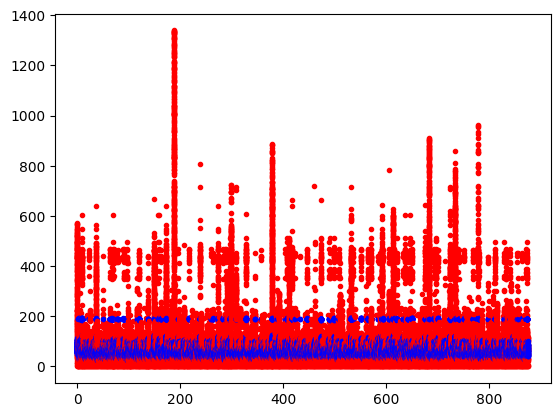

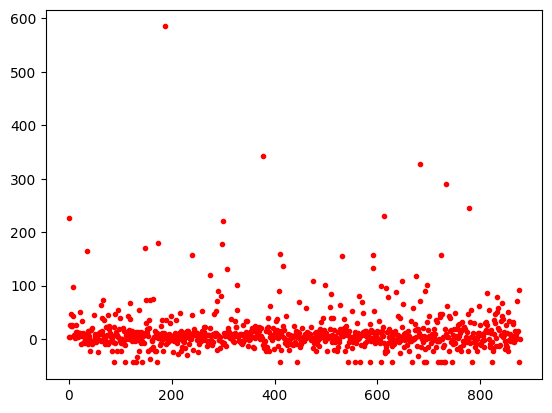

In [98]:
# for 

plt.figure(1)
print(len(orig))
print(len(out))
for id, (i, o) in enumerate(zip(orig, out)):
    # print(i[:,0])
    # print(o[:,0])
    # break
    plt.plot([id*n for n in np.ones(len(o[:,0]),)], i[0],'r.')
    plt.plot([id*n for n in np.ones(len(o[:,0]),)], o[:,0],'b.')
    # plt.hold(True)

print(len(orig))
print(len(out))
plt.figure(0)
for id, (i, o) in enumerate(zip(orig, out)):
    # print(i[:,0])
    # print(o[:,0])
    # break
    # plt.plot([id*n for n in np.ones(len(o[:,1]),)], [a - b for a,b in zip(i[0][:,1], o[:,1])], 'r.')
    err = [a - b for a,b in zip(i[0], o[:,0])]
    plt.plot(id, np.mean(err), 'r.')


# import matplotlib.pyplot as plt 
# print(len(orig))
# print(len(out))
# for id, (i, o) in enumerate(zip(orig, out)):
#     # print(i[:,0])
#     # print(o[:,0])
#     # break
#     plt.plot([id*n for n in np.ones(len(o[:,1]),)], i[0][:,1],'r.')
#     plt.plot([id*n for n in np.ones(len(o[:,1]),)], o[:,1],'b.')
#     # plt.hold(True)


# import matplotlib.pyplot as plt 
# print(len(orig))
# print(len(out))
# for id, (i, o) in enumerate(zip(orig, out)):
#     # print(i[:,0])
#     # print(o[:,0])
#     # break
#     # plt.plot([id*n for n in np.ones(len(o[:,1]),)], [a - b for a,b in zip(i[0][:,1], o[:,1])], 'r.')
#     err = [a - b for a,b in zip(i[0][:,1], o[:,1])]
#     plt.plot(id, np.mean(err), 'r.')

#     # plt.plot([id*n for n in np.ones(len(o[:,1]),)], o[:,1],'b.')
#     # break
#     # plt.hold(True)

In [83]:
plt.figure(1)
print(len(orig))
print(len(out))
for id, (i, o) in enumerate(zip(orig, out)):
    print(i[:,0])
    print(o[:,0])
    break
    plt.plot([id*n for n in np.ones(len(o[:,0]),)], i[0][:,0],'r.')
    plt.plot([id*n for n in np.ones(len(o[:,0]),)], o[:,0],'b.')
    # plt.hold(True)

print(len(orig))
print(len(out))
plt.figure(0)
for id, (i, o) in enumerate(zip(orig, out)):
    # print(i[:,0])
    # print(o[:,0])
    # break
    # plt.plot([id*n for n in np.ones(len(o[:,1]),)], [a - b for a,b in zip(i[0][:,1], o[:,1])], 'r.')
    err = [a - b for a,b in zip(i[0][:,0], o[:,0])]
    plt.plot(id, np.mean(err), 'r.')


# import matplotlib.pyplot as plt 
# print(len(orig))
# print(len(out))
# for id, (i, o) in enumerate(zip(orig, out)):
#     # print(i[:,0])
#     # print(o[:,0])
#     # break
#     plt.plot([id*n for n in np.ones(len(o[:,1]),)], i[0][:,1],'r.')
#     plt.plot([id*n for n in np.ones(len(o[:,1]),)], o[:,1],'b.')
#     # plt.hold(True)


# import matplotlib.pyplot as plt 
# print(len(orig))
# print(len(out))
# for id, (i, o) in enumerate(zip(orig, out)):
#     # print(i[:,0])
#     # print(o[:,0])
#     # break
#     # plt.plot([id*n for n in np.ones(len(o[:,1]),)], [a - b for a,b in zip(i[0][:,1], o[:,1])], 'r.')
#     err = [a - b for a,b in zip(i[0][:,1], o[:,1])]
#     plt.plot(id, np.mean(err), 'r.')

#     # plt.plot([id*n for n in np.ones(len(o[:,1]),)], o[:,1],'b.')
#     # break
#     # plt.hold(True)

877
877
tensor([0.])
tensor([53.4340, 53.5966, 54.3798, 53.9981, 54.1367, 54.6955, 53.7604, 54.3046,
        54.4516, 54.6843, 54.1632, 54.3171, 54.5773, 54.7142, 54.8621, 54.6110,
        55.0143, 55.1603, 55.2967, 55.4476, 55.6012, 55.7532, 55.9299, 55.9246,
        56.0507, 56.2752, 56.2845, 56.2250, 56.3434, 56.0745, 56.1474, 56.2634,
        56.3789, 55.8904, 56.1736, 56.1626, 56.1738, 56.1582])
877
877


IndexError: too many indices for tensor of dimension 1

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt 
plt.plot(embed)

In [334]:
# folder_graph = './data/quorum_sims_all/graphs/train_means/'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle') and file.startswith('(')] #and (file not in files_test)


# fname = 'small_graphs.pth'
valfolder = './data/multirunsims/graphs/test/'
files_val= os.listdir(valfolder)
files_val = [file for file in files_val if file.endswith('.pickle') and file.startswith('(')]

3.234086081047525


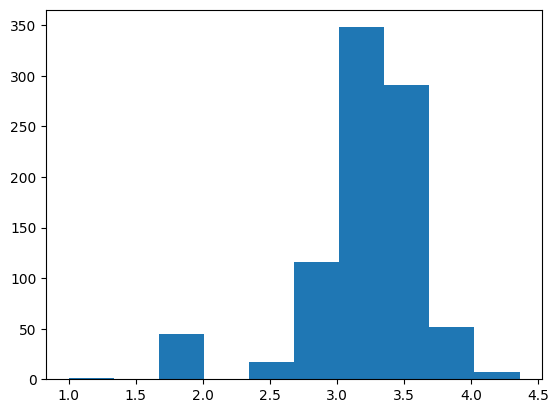

In [335]:
# arr_times_train = []
arr_times_test = []
# arr_success_train = []
arr_success_test = []
import networkx as nx
node_degrees = []
def average_degree(graph):
    # Get the degrees of all nodes
    degrees = dict(graph.degree())
    # Sum the degrees
    total_degree = sum(degrees.values())
    # Calculate the average degree
    avg_degree = total_degree / graph.number_of_nodes()
    return avg_degree

for file in files_val:
    # print(valfolder+file, 'rb')
    fil = open(valfolder+file, 'rb')
    G = pickle.load(fil)
    for node in G.nodes(data=True):
        arr_times_test.append(node[1]['times_conved'])
        arr_success_test.append(node[1]['success'])
    avg_deg = average_degree(G)
    node_degrees.append(avg_deg)

import matplotlib.pyplot as plt 
plt.hist(node_degrees)
print(np.mean(node_degrees))


Text(0, 0.5, 'number of nodes')

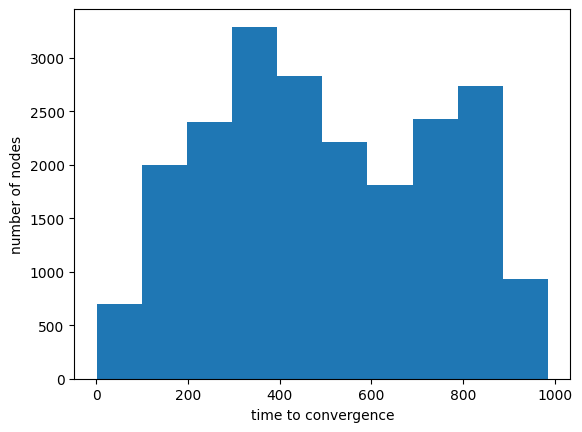

In [21]:
import matplotlib.pyplot as plt 
plt.hist(arr_times_test)
plt.xlabel('time to convergence')
plt.ylabel('number of nodes')

Text(0, 0.5, 'number of nodes')

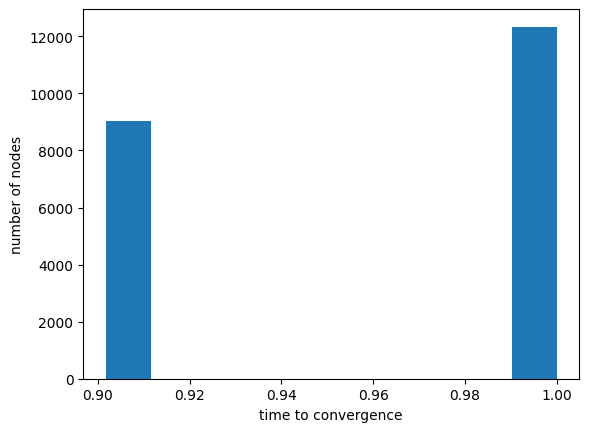

In [22]:
import matplotlib.pyplot as plt 
plt.hist(arr_success_test)
plt.xlabel('time to convergence')
plt.ylabel('number of nodes')

3.739594227852765


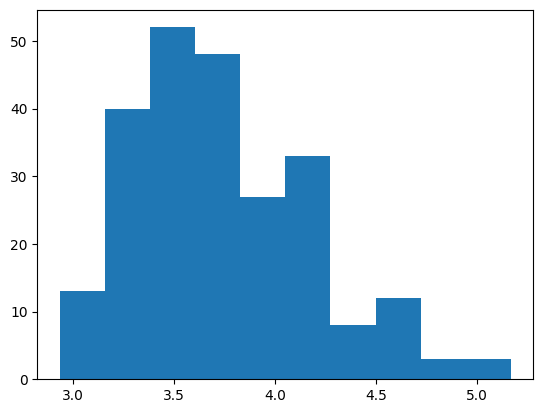

In [76]:
arr_times_train = []
arr_times_test = []
arr_success_train = []
arr_success_test = []
import networkx as nx
node_degrees = []
def average_degree(graph):
    # Get the degrees of all nodes
    degrees = dict(graph.degree())
    # Sum the degrees
    total_degree = sum(degrees.values())
    # Calculate the average degree
    avg_degree = total_degree / graph.number_of_nodes()
    return avg_degree


# fname = 'small_graphs.pth'
valfolder = './data/multirunsims/graphs/test/'
files_val= os.listdir(valfolder)
files_val = [file for file in files_val if file.endswith('.pickle') and file.startswith('(')]
folder_graph = './data/multirunsims/graphs/train/'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle') and file.startswith('(')] #and (file not in files_test)



for file in files_val:
    # print(valfolder+file, 'rb')
    fil = open(valfolder+file, 'rb')
    G = pickle.load(fil)
    for node in G.nodes(data=True):
        arr_times_test.append(node[1]['times_conved'])
        arr_success_test.append(node[1]['success'])
    avg_deg = average_degree(G)
    node_degrees.append(avg_deg)

import matplotlib.pyplot as plt 
plt.hist(node_degrees)
print(np.mean(node_degrees))


Text(0, 0.5, 'number of nodes')

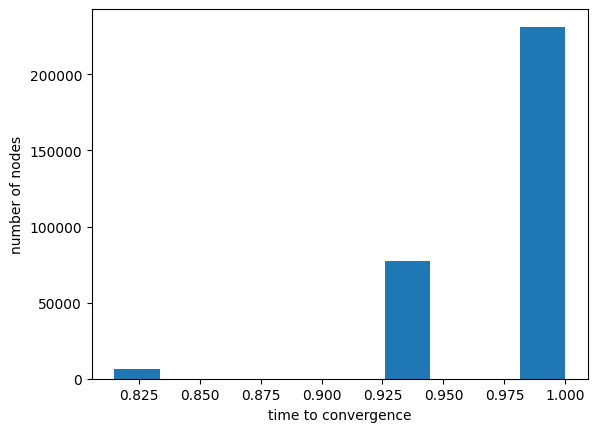

In [77]:

# import matplotlib.pyplot as plt 
plt.hist(arr_success_test)
plt.xlabel('time to convergence')
plt.ylabel('number of nodes')


Text(0, 0.5, 'number of nodes')

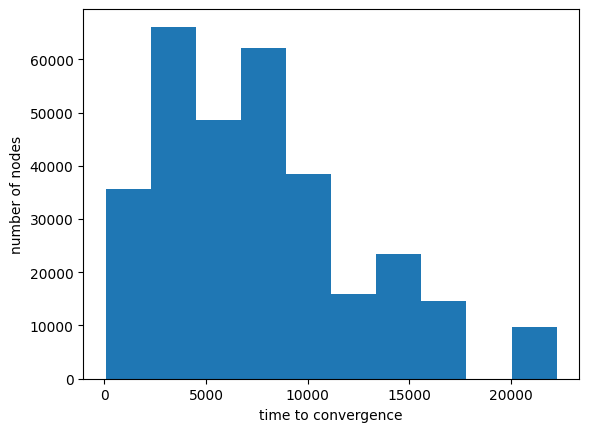

In [78]:

# import matplotlib.pyplot as plt 
plt.hist(arr_times_test)
plt.xlabel('time to convergence')
plt.ylabel('number of nodes')

Text(0, 0.5, 'number of nodes')

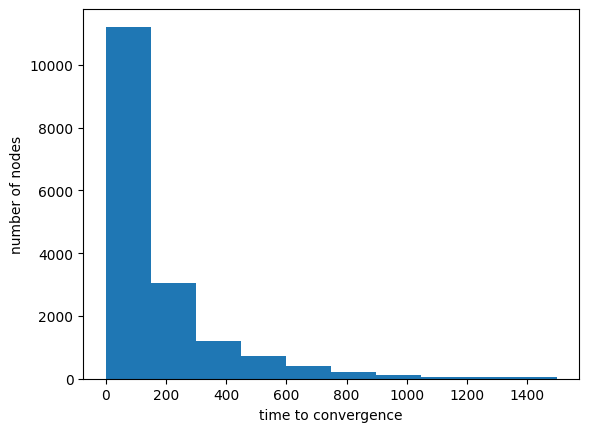

In [336]:
import pickle
fil2 = open('./data/multirunsims/graphs/alltraintime.pickle', 'rb')
metatime = pickle.load(fil2)
fil2.close()

fil2 = open('./data/multirunsims/graphs/alltrainsucc.pickle', 'rb')
metasucc = pickle.load(fil2)
fil2.close()

SUCC_LIMIT = 0.95
TIME_LIMIT = 500  

mean_times = []
mean_succ = []
for node in metatime:
    mean_times.append(np.mean(metatime[node]))
    mean_succ.append(np.mean(metasucc[node]))

plt.hist(mean_times)
plt.xlabel('time to convergence')
plt.ylabel('number of nodes')

Text(0, 0.5, 'number of nodes')

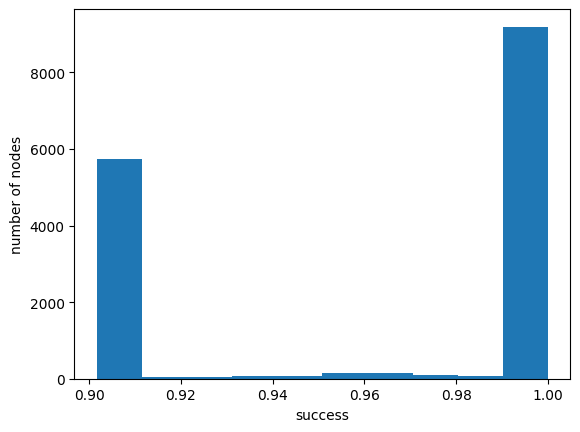

In [34]:

plt.hist(mean_succ)
plt.xlabel('success')
plt.ylabel('number of nodes')

In [35]:
mean_times = []
mean_succ = []
for node in metatime:
    mean_times.append(np.mean(metatime[node]))
    mean_succ.append(np.mean(metasucc[node]))
    # print('mean times')
    print(metatime[node], np.mean(metatime[node]))
    print(metasucc[node], np.mean(metasucc[node]))
    break


[50, 49, 34, 33, 32, 31, 68, 38, 37, 36, 57, 56, 59, 58, 57, 56, 55, 66, 65, 30, 29, 28, 112, 53, 52, 51, 50, 49, 48, 47, 46, 64, 63, 55, 54, 66, 65, 135, 134, 133, 132, 57, 56, 55, 54, 45, 61, 73, 72, 29, 28, 76, 75, 61, 44, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 105, 104, 80, 79, 179, 178, 177, 176, 175, 130, 129, 128, 127, 118, 150, 149, 148, 92, 91, 90, 64, 63, 62, 61, 153, 152, 149, 148, 50, 49, 58, 71, 70, 73, 72, 71, 87, 127, 126, 57, 62, 57, 56, 55, 54, 155, 59] 75.44642857142857
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 

Text(0, 0.5, 'number of nodes')

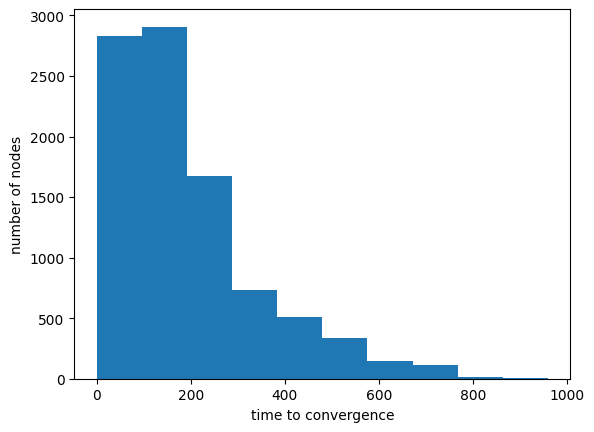

In [31]:
import pickle
fil2 = open('./data/1000_len_sims/graphs/alltesttime.pickle', 'rb')
metatime = pickle.load(fil2)
fil2.close()

fil2 = open('./data/1000_len_sims/graphs/alltestsucc.pickle', 'rb')
metasucc = pickle.load(fil2)
fil2.close()

SUCC_LIMIT = 0.95
TIME_LIMIT = 500  

mean_times = []
mean_succ = []
for node in metatime:
    mean_times.append(np.mean(metatime[node]))
    mean_succ.append(np.mean(metasucc[node]))

plt.hist(mean_times)
plt.xlabel('time to convergence')
plt.ylabel('number of nodes')

Text(0, 0.5, 'number of nodes')

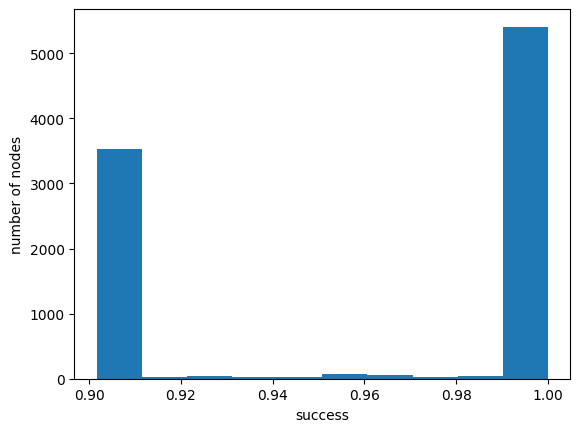

In [32]:

plt.hist(mean_succ)
plt.xlabel('success')
plt.ylabel('number of nodes')

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def probability_weighted_confusion_matrix(y_true, y_probs, n_classes):
    """
    Create a probability-weighted confusion matrix.

    Parameters:
    y_true (array-like): True class labels.
    y_probs (array-like): Predicted probabilities for each class.
    n_classes (int): Number of classes.

    Returns:
    np.ndarray: Probability-weighted confusion matrix.
    """
    matrix = np.zeros((n_classes, n_classes))

    for true_class, probs in zip(y_true, y_probs):
        for pred_class, prob in enumerate(probs):
            matrix[true_class, pred_class] += prob

    return matrix

  
def get_succtimeclass(s, t, fl):

    if s <= SUCC_LIMIT and t > TIME_LIMIT:
        return 0 # slow fail
    elif s > SUCC_LIMIT and t > TIME_LIMIT:
        return 1 # slow success
    elif s <= SUCC_LIMIT and t <= TIME_LIMIT:
        return 2 # fast fail
    elif s > SUCC_LIMIT and t <= TIME_LIMIT:
        return 3 # fast success
    else:
        print(s, t, fl)
        # pdb.set_trace()

def get_ratio(time, succ):
    class_arr = []

    for times, successes in zip(time, succ):
        class_arr.append(get_succtimeclass(successes, times,''))

    percent_class = [0]*4
    for i in class_arr:
        percent_class[i] += 1.0
    total = np.sum(percent_class)
    percent_class = [p/total for p in percent_class]
    return percent_class, class_arr


arr = []
classestrue = []
# for times, successes in zip(metatime.values(), metasucc.values()):
for m in metatime:
    # print(m)
    # pdb.set_trace()
    # print(metatime[m])
    # print(metasucc[m])
    perc, classes = get_ratio(metatime[m], metasucc[m])
    arr.append(perc)
    classestrue.append(classes)



In [10]:
print(np.sum(arr, axis = 0))

cm = probability_weighted_confusion_matrix(classestrue, arr, 4)
# print(np.shape(arr))
# print(np.shape(classestrue))
# len(classestrue)

[11229.82460752 34926.85565295 11606.48854768 32047.83119185]


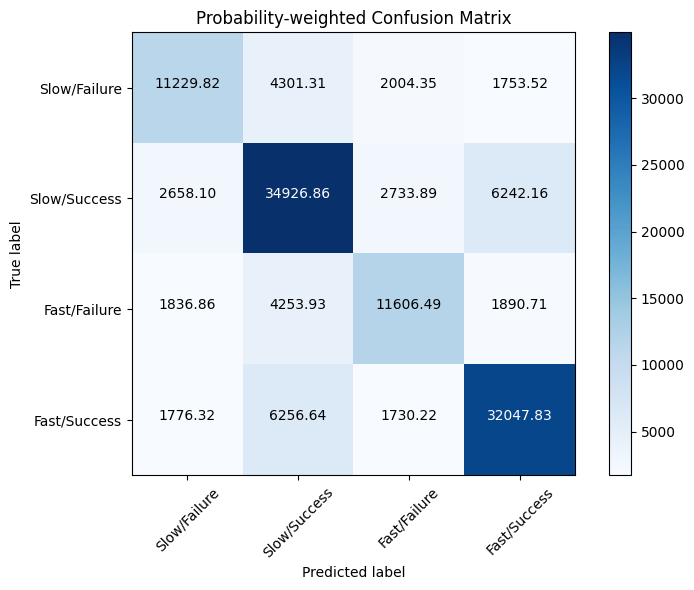

In [11]:

def plot_confusion_matrix(cm, classes, title='Probability-weighted Confusion Matrix', cmap=plt.cm.Blues):
    """
    Plot the confusion matrix.

    Parameters:
    cm (np.ndarray): Confusion matrix.
    classes (list): List of class names.
    title (str): Title of the plot.
    cmap: Colormap for the plot.
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
CLIST =  ["Slow/Failure", "Slow/Success", "Fast/Failure", "Fast/Success"]

plot_confusion_matrix(cm,CLIST)

Text(0, 0.5, 'number of nodes')

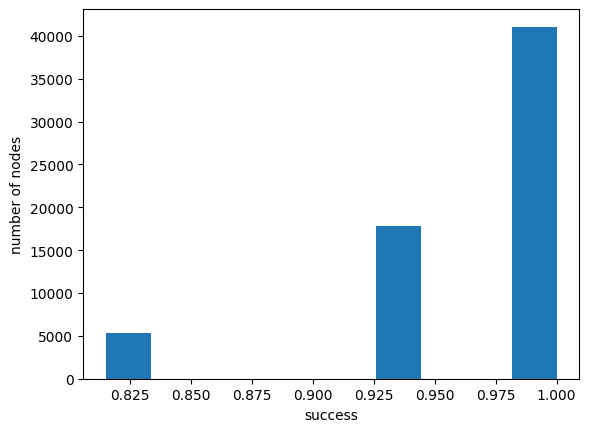

In [15]:
plt.hist(arr_success_test)
plt.xlabel('success')
plt.ylabel('number of nodes')

In [107]:

# quorum_sims_60_40_split

fil2 = open('./data/quorum_sims_60_40_split/graphs/alltesttime.pickle', 'rb')
metatime = pickle.load(fil2)
fil2.close()

fil2 = open('./data/quorum_sims_60_40_split/graphs/alltestsucc.pickle', 'rb')
metasucc = pickle.load(fil2)
fil2.close()

! ls -a './data/quorum_sims_60_40_split/graphs/' 

.                      alltesttime.pickle     test_means
..                     alltrainsucc.pickle    train
.DS_Store              alltraintime.pickle    train_means
alltestsucc.pickle     test                   train_near_convergence


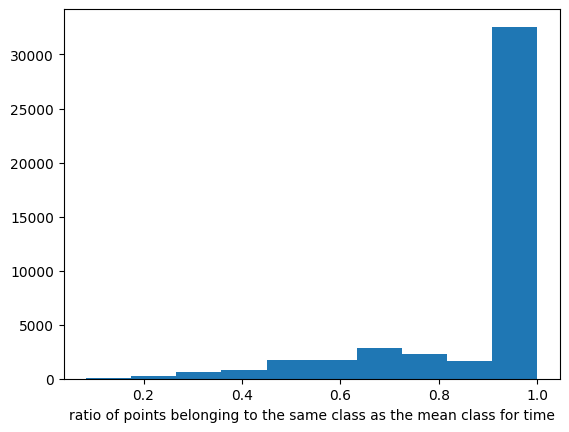

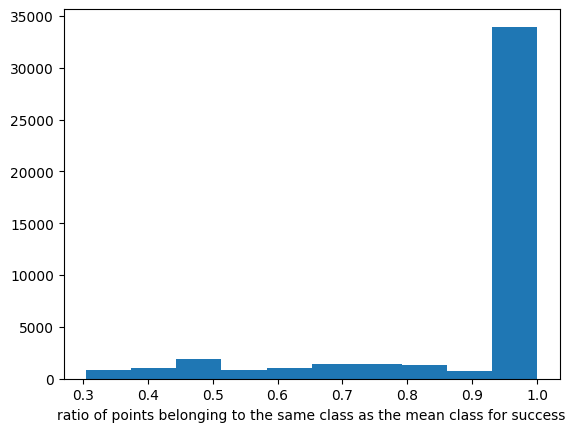

In [12]:
import pdb
def get_succtimeclass(s, t, fl):

    if s <= SUCC_LIMIT and t > TIME_LIMIT:
        return 0 # slow fail
    elif s > SUCC_LIMIT and t > TIME_LIMIT:
        return 1 # slow success
    elif s <= SUCC_LIMIT and t <= TIME_LIMIT:
        return 2 # fast fail
    elif s > SUCC_LIMIT and t <= TIME_LIMIT:
        return 3 # fast success
    else:
        print(s, t, fl)
        pdb.set_trace()

def get_timeclass( t):
    if t > TIME_LIMIT:
        return 0
    else:
        return 1
    
def get_succclass( s):
    if s <= SUCC_LIMIT:
        return 0
    else:
        return 1

TIME_LIMIT = 2500
SUCC_LIMIT = 0.95

numentries = []
class_mean_time = []
classes_indi_time = []
class_mean_succ = []
classes_indi_succ = []
# traintimes = []
# trainsuccess = []
for m in metatime:
    # print(metatime[m])
    # print(metasucc[m])
    # pdb.set_trace()
    class_mean_time.append(get_timeclass(np.mean(metatime[m])))
    class_mean_succ.append(get_succclass(np.mean(metasucc[m])))
    time_arr = []
    succ_arr = []
    for times, succ in zip(metatime[m], metasucc[m]):
        time_arr.append(get_timeclass(times))
        succ_arr.append(get_succclass(succ))
    classes_indi_time.append(time_arr)
    classes_indi_succ.append(succ_arr)
    numentries.append(len(metatime[m]))

percent_time_classes = []
percent_succ_classes = []
# for ctmean, csmean, ct, cs in zip(class_mean_time, class_mean_succ, classes_indi_time, classes_indi_succ):
#     # pdb.set_trace()
#     percent_time_classes.append(np.mean([ctmean  if c==ctmean else 0 for c in ct]))
#     percent_succ_classes.append(np.mean([csmean if c==csmean else 0 for c in cs]))

# t1 = []
# t2 = []
# t3 = []
# t4 = []
# for i in range(0,4):
#     for ctmean, csmean, ct, cs in zip(class_mean_time, class_mean_succ, classes_indi_time, classes_indi_succ):




for ctmean, csmean, ct, cs in zip(class_mean_time, class_mean_succ, classes_indi_time, classes_indi_succ):
    # pdb.set_trace()
    if ctmean == 0 and csmean == 1:
        percent_time_classes.append(np.mean([1  if c==ctmean else 0 for c in ct]))
        percent_succ_classes.append(np.mean([1 if c==csmean else 0 for c in cs]))
plt.hist(percent_time_classes)#, '.')
plt.xlabel('ratio of points belonging to the same class as the mean class for time')
# plt.xlabel('node number')
plt.show()

plt.hist(percent_succ_classes)#, '.')
plt.xlabel('ratio of points belonging to the same class as the mean class for success')
# plt.xlabel('node number')
plt.show()
# percent_time_classes = np.mean([c/np.sum([]) for c in class_mean_time])
# percent_succ_classes = 

    # break
        
# for m in metatime:
#     print(metatime[m])
#     for times in metatime[m]:
#         traintimes.append(times)

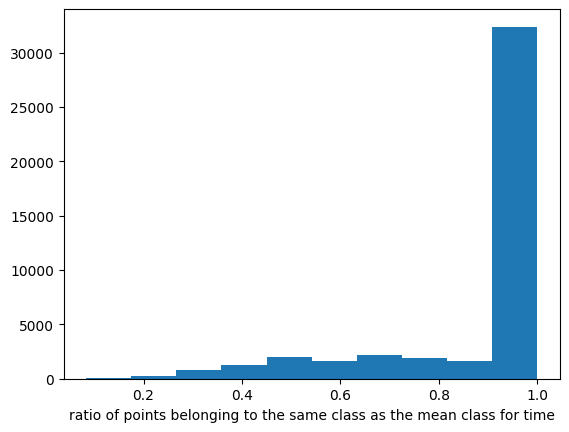

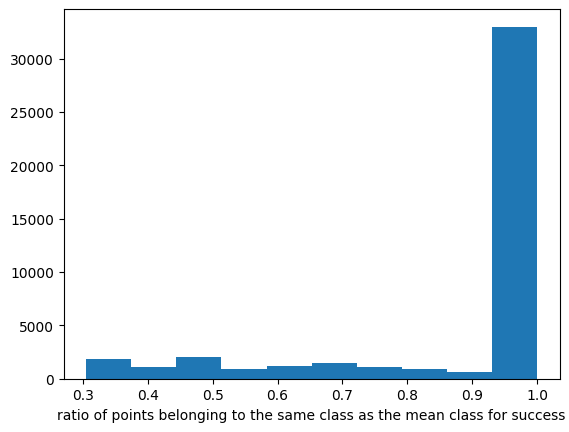

Text(0, 0.5, 'number of nodes')

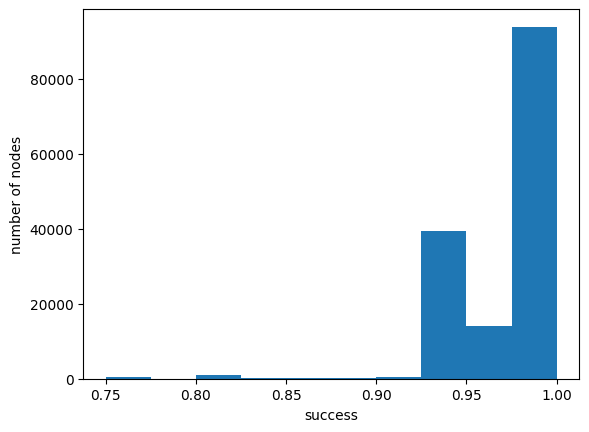

In [57]:
plt.hist(trainsuccess)
plt.xlabel('success')
plt.ylabel('number of nodes')

Text(0, 0.5, 'number of nodes')

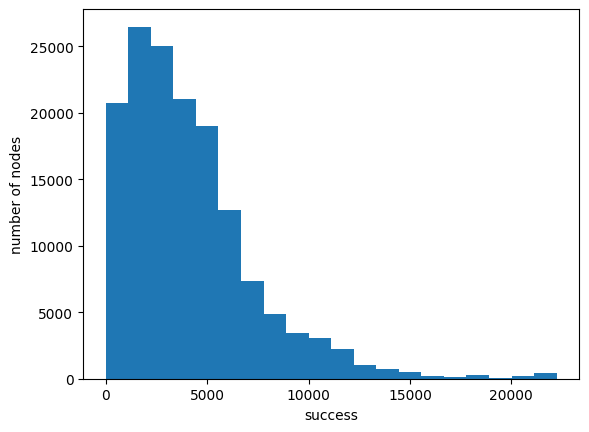

In [54]:
plt.hist(traintimes, bins=20)
plt.xlabel('success')
plt.ylabel('number of nodes')

In [ ]:
# plt.plot(h[1][:-1],h[0],'.')
# plt.xlabel('success')
# plt.ylabel('number of nodes')